# — Visualization

This notebook presents the main visual results of the
electricity forecasting experiments.

The notebook does not train or forecast any model.

It uses outputs generated by:

- `01_data_exploration.ipynb`
- `02_baselines.ipynb`
- `03_chronos2_forecasting.ipynb`
- `04_evaluation.ipynb`

The main figures are:

1. Historical electricity consumption
2. Actual vs Chronos-2 forecast
3. Model comparison
4. Forecast-horizon comparison

In [1]:
import sys
from pathlib import Path

import pandas as pd

from darts import TimeSeries

PROJECT_ROOT = Path.cwd().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from src.data import load_dataset

from src.evaluation import (
    load_metrics,
    load_forecasts,
)

from src.visualization import (
    plot_historical_data,
    plot_actual_vs_chronos,
    plot_actual_vs_models,
    plot_model_comparison,
    plot_forecast_horizons,
    plot_all_models_horizons,
    plot_saved_forecasts,
    get_figures_directory,
)

## Configuration

In [2]:
DATA_PATH = (
    PROJECT_ROOT
    / "data"
    / "raw"
    / "LD2011_2014.txt"
)

RESULTS_DIR = (
    PROJECT_ROOT / "results"
)

FIGURES_DIR = get_figures_directory(
    RESULTS_DIR
)

SERIES_ID = "MT_001"

HORIZON_24H = 96
HORIZON_48H = 192
HORIZON_7D = 672

print(
    "Figures directory:",
    FIGURES_DIR
)

Figures directory: c:\Users\palla\OneDrive\Desktop\nita-sem-3\ak-pu\chronos-2\results\figures


## Load Metrics

In [3]:
metrics = load_metrics(
    RESULTS_DIR / "metrics.csv"
)

display(metrics)

,Model,Series_ID,Horizon,MAE,RMSE
0,Naive Seasonal (Daily),MT_001,96,1.136844,2.795961
1,Naive Seasonal (Daily),MT_001,192,1.083968,2.450641
2,Naive Seasonal (Daily),MT_001,672,1.136844,2.409219
3,"ARIMA(12,1,0)",MT_001,96,0.756977,0.978251
4,Chronos-2,MT_001,96,0.763720,1.182067
5,Chronos-2,MT_001,192,0.795465,1.208076
6,Chronos-2,MT_001,672,0.964219,1.799736


## Load Forecast

In [4]:
forecasts = load_forecasts(
    RESULTS_DIR / "forecasts.csv"
)

display(
    forecasts.head()
)

print(
    "Forecast rows:",
    len(forecasts)
)

,timestamp,series_id,model_name,horizon,value
0,2014-03-14 19:15:00,MT_001,Naive Seasonal (Daily),96,2.538071
1,2014-03-14 19:30:00,MT_001,Naive Seasonal (Daily),96,1.269036
2,2014-03-14 19:45:00,MT_001,Naive Seasonal (Daily),96,2.538071
3,2014-03-14 20:00:00,MT_001,Naive Seasonal (Daily),96,2.538071
4,2014-03-14 20:15:00,MT_001,Naive Seasonal (Daily),96,1.269036


Forecast rows: 2016


## Historical data

In [5]:
df = load_dataset(
    str(DATA_PATH)
)

series_df = (
    df[
        df["series_id"] == SERIES_ID
    ]
    .sort_values("timestamp")
    .reset_index(drop=True)
)

series = TimeSeries.from_dataframe(
    series_df,
    time_col="timestamp",
    value_cols="value",
)

Loading dataset: c:\Users\palla\OneDrive\Desktop\nita-sem-3\ak-pu\chronos-2\data\raw\LD2011_2014.txt


c:\Users\palla\OneDrive\Desktop\nita-sem-3\ak-pu\chronos-2\src\data.py:70: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df = df.reset_index()


Raw shape: (140256, 371)


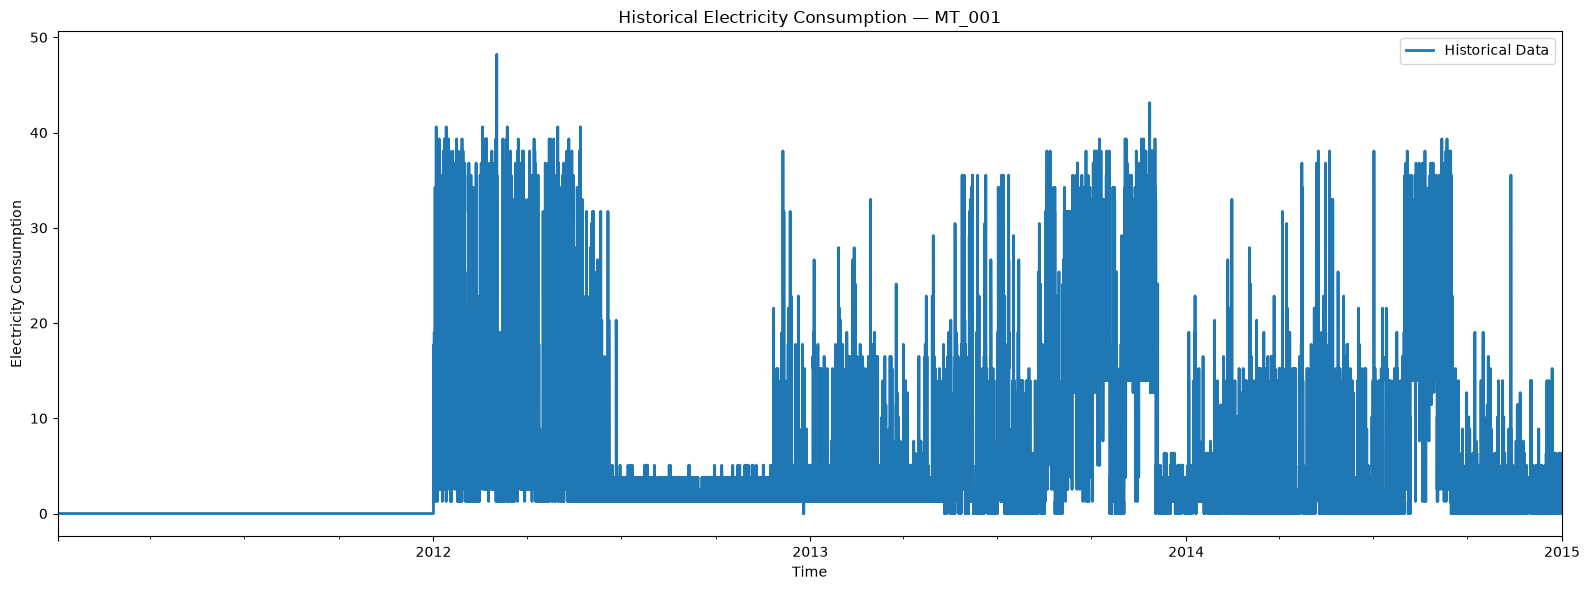

In [6]:
plot_historical_data(
    series=series,
    series_id=SERIES_ID,
    save_path=(
        FIGURES_DIR
        / "figure_1_historical_data.png"
    ),
)

## Actual vs Chronos

In [7]:
actuals = pd.read_csv(
    RESULTS_DIR / "actuals.csv",
    parse_dates=["timestamp"],
)

display(
    actuals.head()
)

,timestamp,series_id,horizon,value
0,2014-03-14 19:15:00,MT_001,96,2.538071
1,2014-03-14 19:30:00,MT_001,96,3.807107
2,2014-03-14 19:45:00,MT_001,96,1.269036
3,2014-03-14 20:00:00,MT_001,96,2.538071
4,2014-03-14 20:15:00,MT_001,96,1.269036


In [9]:
actual_24h = actuals[
    (actuals["series_id"] == SERIES_ID)
    &
    (actuals["horizon"] == HORIZON_24H)
].copy()

chronos_24h = forecasts[
    (forecasts["series_id"] == SERIES_ID)
    &
    (forecasts["model_name"] == "Chronos-2")
    &
    (forecasts["horizon"] == HORIZON_24H)
].copy()

In [11]:
actual_series = TimeSeries.from_dataframe(
    actual_24h,
    time_col="timestamp",
    value_cols="value",
)
chronos_series = TimeSeries.from_dataframe(
    chronos_24h,
    time_col="timestamp",
    value_cols="value",
)

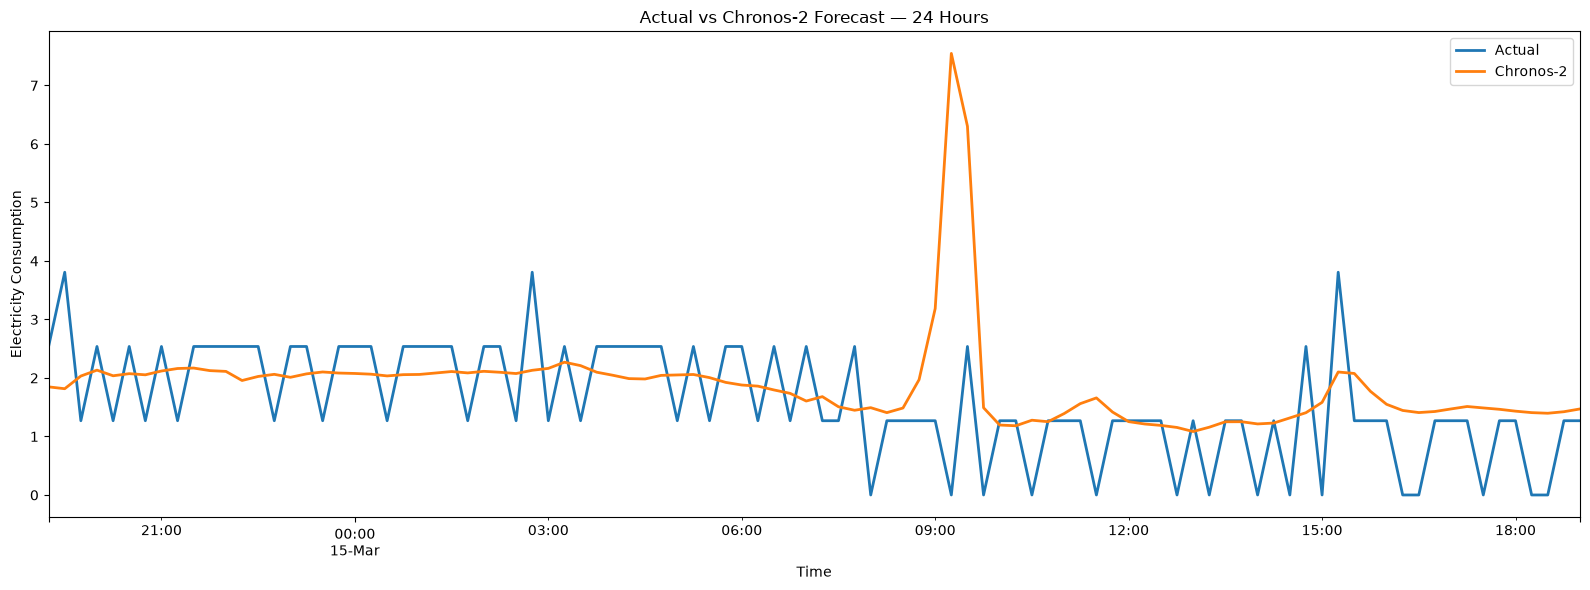

In [12]:
plot_actual_vs_chronos(
    actual=actual_series,
    forecast=chronos_series,
    horizon_label="24 Hours",
    save_path=(
        FIGURES_DIR
        / "figure_2_actual_vs_chronos_24h.png"
    ),
)

In [15]:
naive_24h = forecasts[
    (forecasts["series_id"] == SERIES_ID)
    &
    (forecasts["model_name"] == "Naive Seasonal (Daily)")
    &
    (forecasts["horizon"] == HORIZON_24H)
].copy()

arima_24h = forecasts[
    (forecasts["series_id"] == SERIES_ID)
    &
    (forecasts["model_name"].str.contains("ARIMA"))
    &
    (forecasts["horizon"] == HORIZON_24H)
].copy()

In [16]:
naive_series = TimeSeries.from_dataframe(
    naive_24h,
    time_col="timestamp",
    value_cols="value",
)

arima_series = TimeSeries.from_dataframe(
    arima_24h,
    time_col="timestamp",
    value_cols="value",
)

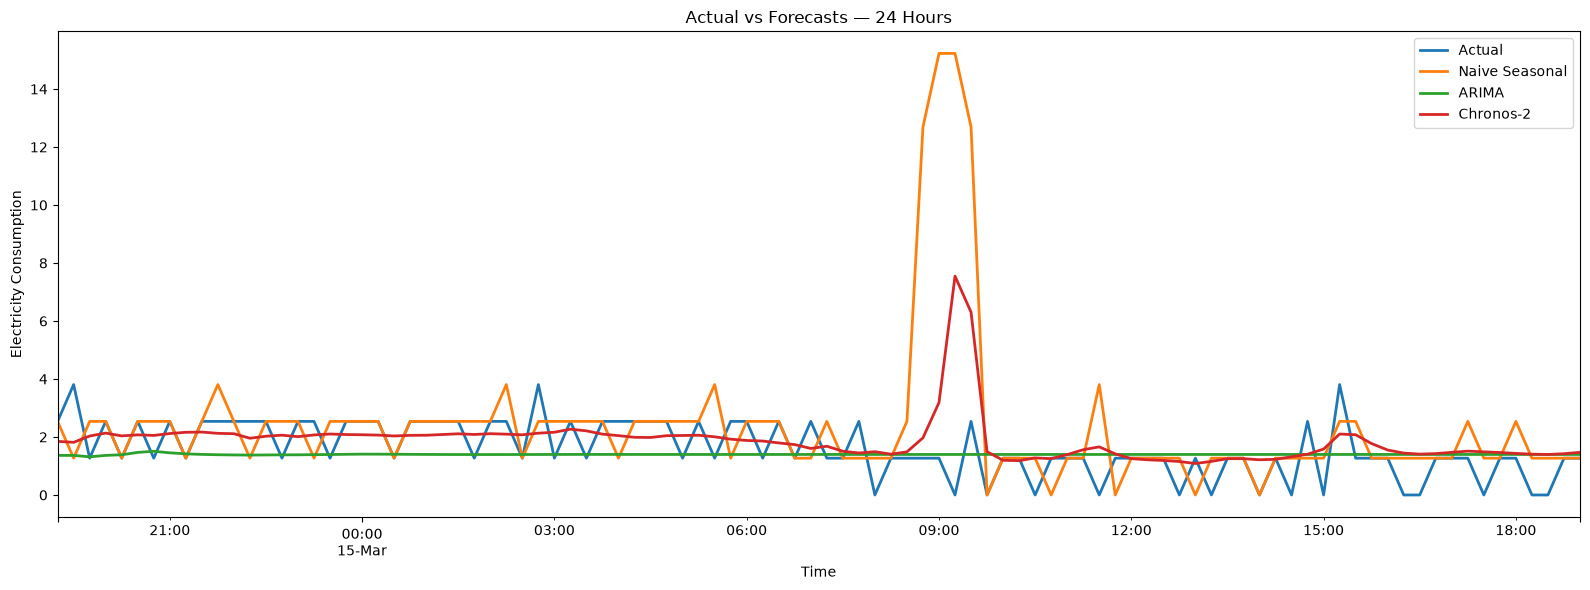

In [17]:
plot_actual_vs_models(
    actual=actual_series,
    forecasts={
        "Naive Seasonal": naive_series,
        "ARIMA": arima_series,
        "Chronos-2": chronos_series,
    },
    title="Actual vs Forecasts — 24 Hours",
    save_path=(
        FIGURES_DIR
        / "figure_2_actual_vs_models_24h.png"
    ),
)

## Model Comparision

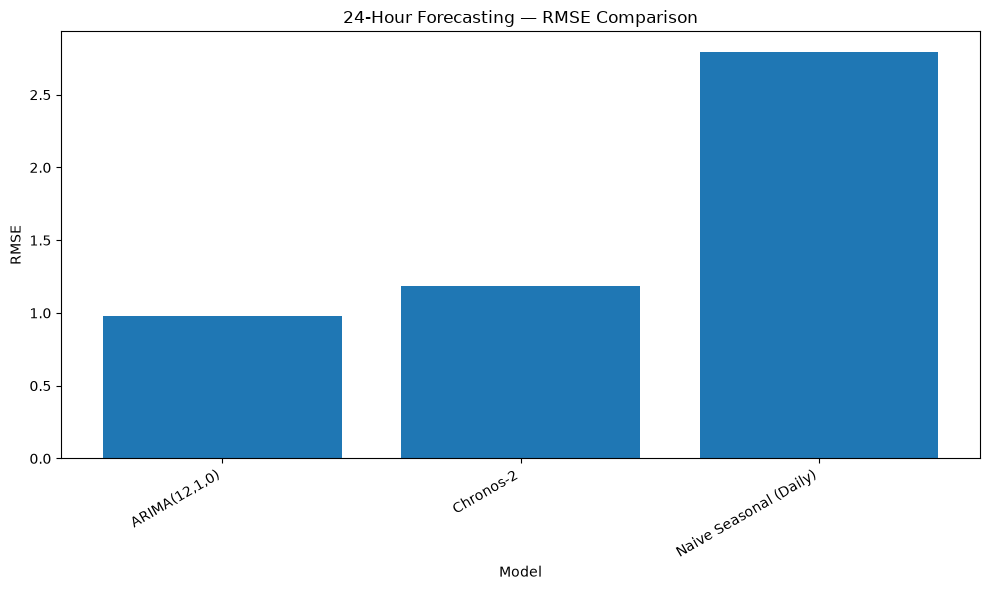

In [18]:
plot_model_comparison(
    metrics=metrics,
    metric="RMSE",
    horizon=HORIZON_24H,
    title="24-Hour Forecasting — RMSE Comparison",
    save_path=(
        FIGURES_DIR
        / "figure_3_model_comparison_rmse_24h.png"
    ),
)

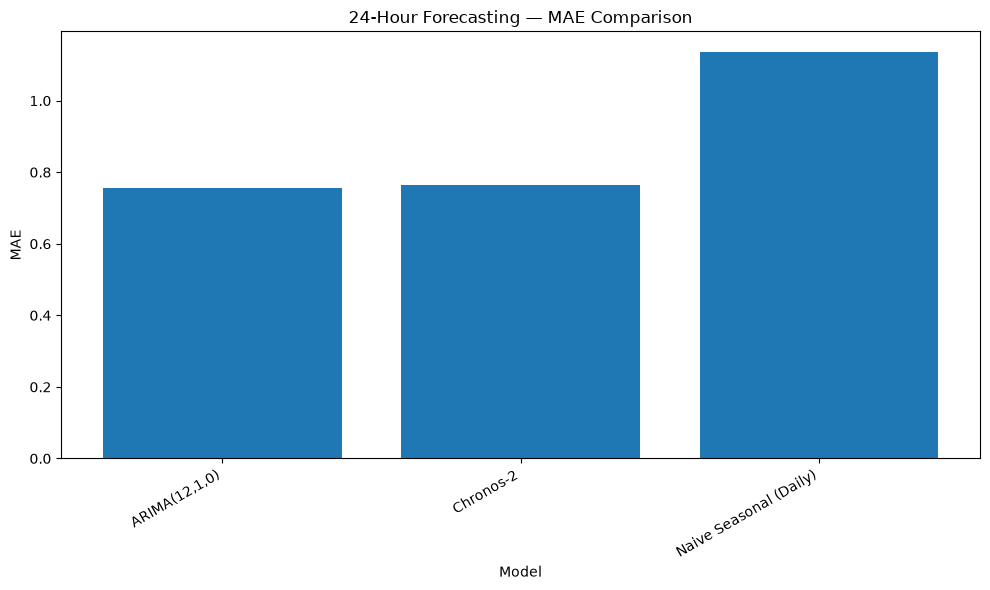

In [19]:
plot_model_comparison(
    metrics=metrics,
    metric="MAE",
    horizon=HORIZON_24H,
    title="24-Hour Forecasting — MAE Comparison",
    save_path=(
        FIGURES_DIR
        / "figure_3_model_comparison_mae_24h.png"
    ),
)

## Different Chronos horizons

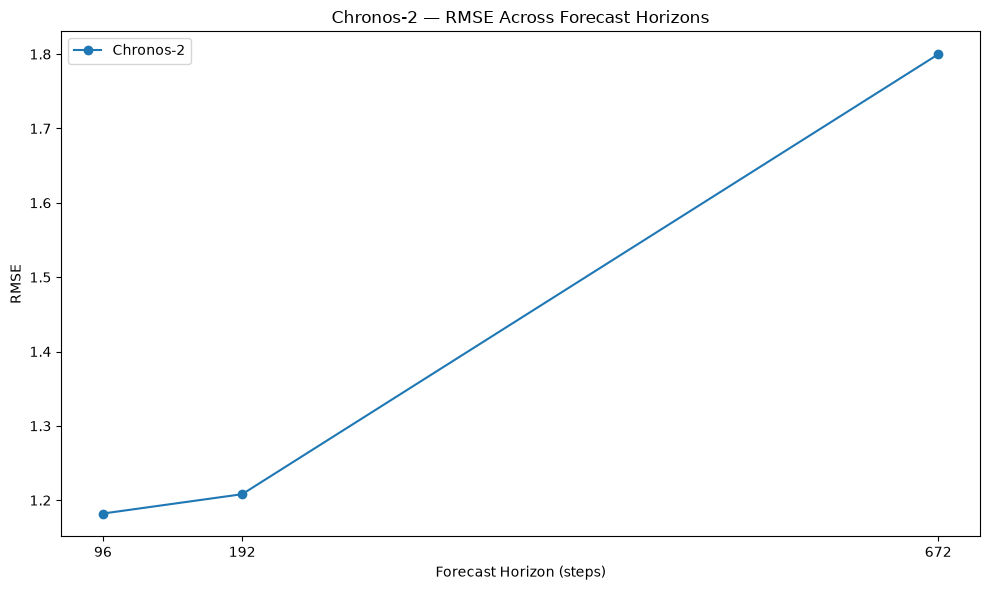

In [20]:
plot_forecast_horizons(
    metrics=metrics,
    metric="RMSE",
    model_name="Chronos-2",
    save_path=(
        FIGURES_DIR
        / "figure_4_chronos_horizons_rmse.png"
    ),
)

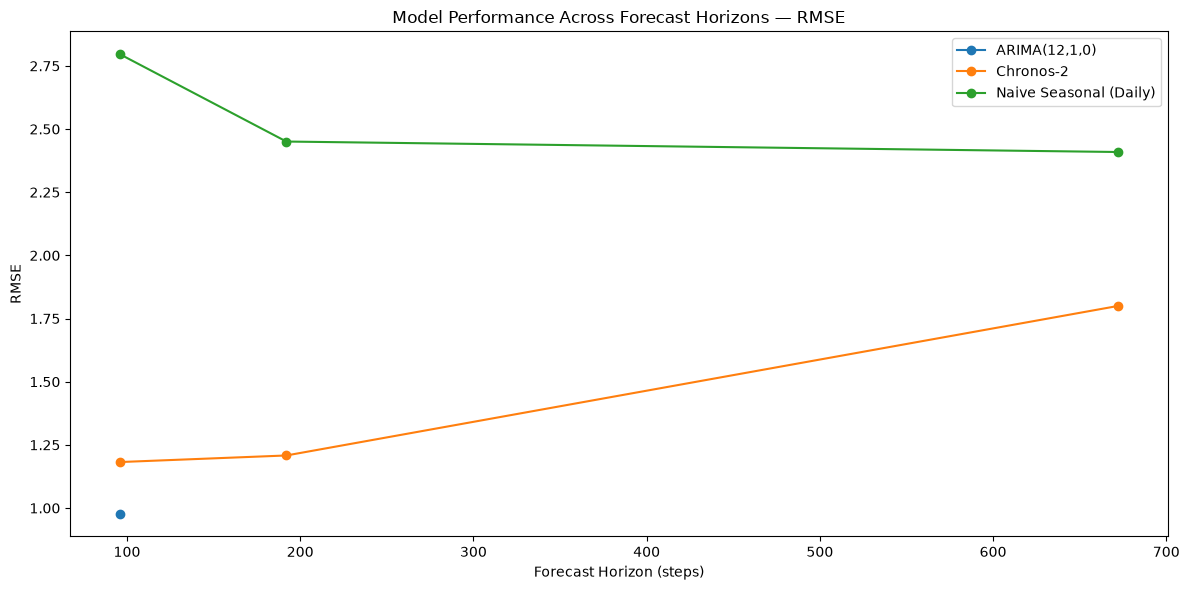

In [21]:
plot_all_models_horizons(
    metrics=metrics,
    metric="RMSE",
    save_path=(
        FIGURES_DIR
        / "figure_4_all_models_horizons_rmse.png"
    ),
)

In [22]:
print("Generated figures:")
print("------------------")

for figure in sorted(
    FIGURES_DIR.glob("*.png")
):
    print(
        figure.name
    )

Generated figures:
------------------
figure_1_historical_data.png
figure_2_actual_vs_chronos_24h.png
figure_2_actual_vs_models_24h.png
figure_3_model_comparison_mae_24h.png
figure_3_model_comparison_rmse_24h.png
figure_4_all_models_horizons_rmse.png
figure_4_chronos_horizons_rmse.png
